# 🔫 Weapon Detection — Transfer Learning & Fine-Tuning (YOLO11s.pt)

> **Dataset:** `weapon_detection_augmented/` (3 classes: Knife · Pistol · Rifle, YOLO format)  
> **Approach:** YOLO11s pre-trained on COCO → Fine-tuned on weapon detection dataset

---

## Workflow

```
yolo11s.pt  (COCO pre-trained weights — 80 classes)
         │
         ▼
[Step 1] Load model & replace detection head  (3 classes)
         │
         ▼
[Step 2] Frozen backbone fine-tuning  (head-only, fast convergence)
         │
         ▼
[Step 3] Full model fine-tuning  (all layers, lower LR)
         │
         ▼
[Step 4] Evaluation  →  per-class mAP · PR curves · Confusion Matrix
         │
         ▼
[Step 5] Comparison  →  Scratch vs Fine-tuned metrics dashboard
```

---


---
## Phase 0 — Environment Setup & Global Configuration


In [1]:
import os, sys, math, random, time, shutil, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import yaml
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

# ── Path Configuration ─────────────────────────────────────────────────────────
AUGMENTED_PATH = r"C:\Users\Admin\Downloads\weapon detection\weapon_detection_augmented"
DATA_YAML      = os.path.join(AUGMENTED_PATH, "data.yaml")

# ── Class Configuration ────────────────────────────────────────────────────────
CLASSES      = ["Knife", "Pistol", "Rifle"]
NC           = len(CLASSES)
CLASS_COLORS = {"Knife": "#E74C3C", "Pistol": "#3498DB", "Rifle": "#2ECC71"}
PALETTE      = list(CLASS_COLORS.values())

# ── Random Seed ────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Plotting Defaults ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":          120,
    "figure.facecolor":    "#FAFAFA",
    "axes.facecolor":      "#FAFAFA",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.titlesize":      14,
    "axes.titleweight":    "bold",
    "axes.labelsize":      11,
    "xtick.labelsize":     9,
    "ytick.labelsize":     9,
    "legend.fontsize":     9,
    "font.family":         "DejaVu Sans",
})
sns.set_palette("deep")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 65)
print("  Notebook 2 — Transfer Learning & Fine-Tuning")
print("=" * 65)
print(f"  PyTorch version  : {torch.__version__}")
print(f"  CUDA available   : {torch.cuda.is_available()}")
print(f"  Device           : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU              : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM             : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"  Augmented data   : {AUGMENTED_PATH}")
print(f"  Data YAML        : {DATA_YAML}")
print(f"  Classes ({NC})      : {CLASSES}")
print("=" * 65)


  Notebook 2 — Transfer Learning & Fine-Tuning
  PyTorch version  : 2.6.0+cu124
  CUDA available   : True
  Device           : cuda
  GPU              : NVIDIA RTX 2000 Ada Generation
  VRAM             : 17.2 GB
  Augmented data   : C:\Users\Admin\Downloads\weapon detection\weapon_detection_augmented
  Data YAML        : C:\Users\Admin\Downloads\weapon detection\weapon_detection_augmented\data.yaml
  Classes (3)      : ['Knife', 'Pistol', 'Rifle']


---
## Phase 1 — Load YOLO11s Pre-trained Weights

`yolo11s.pt` is trained on COCO (80 classes). Loading it for our 3-class task  
causes Ultralytics to **automatically rebuild** the detection head to match `nc=3`  
defined in `data.yaml`. The backbone and neck weights are fully preserved.


In [2]:
# ── Install check ──────────────────────────────────────────────────────────────
MIN_ULTRALYTICS_VERSION = "8.1.0"   # YOLO11 support was added in ultralytics 8.3.0+; pin a safe minimum

try:
    from ultralytics import YOLO
    import ultralytics
    from packaging import version
    if version.parse(ultralytics.__version__) < version.parse("8.3.0"):
        raise ImportError(f"ultralytics {ultralytics.__version__} is too old for YOLO11 — upgrading.")
    print(f"  ✅  ultralytics {ultralytics.__version__} available (YOLO11-compatible).")
except ImportError:
    import subprocess
    print("  Installing/upgrading ultralytics for YOLO11 support ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "ultralytics", "-q"])
    from ultralytics import YOLO
    import ultralytics
    print(f"  ✅  ultralytics {ultralytics.__version__} installed and imported.")


  ✅  ultralytics 8.4.83 available (YOLO11-compatible).


In [3]:
# ── Load YOLO11s Pre-trained Model ────────────────────────────────────────────

MODEL_PT    = "yolo11s.pt"    # pre-trained COCO weights (auto-downloaded if absent)

model_ft = YOLO(MODEL_PT)

total_params     = sum(p.numel() for p in model_ft.model.parameters())
trainable_params = sum(p.numel() for p in model_ft.model.parameters() if p.requires_grad)

print("=" * 65)
print(f"  Pre-trained model loaded : {MODEL_PT}")
print(f"  Total parameters         : {total_params:,}")
print(f"  Trainable parameters     : {trainable_params:,}")
print("=" * 65)

# ── Display model architecture summary ─────────────────────────────────────────
print("\n  Model layer summary (first 10 layers):")
for i, (name, module) in enumerate(model_ft.model.named_children()):
    print(f"    [{i:>2}] {name:<25} {module.__class__.__name__}")
    if i >= 9:
        print(f"    ... (total {len(list(model_ft.model.named_children()))} top-level modules)")
        break

print("\n  ✅  Model ready for fine-tuning.")


  Pre-trained model loaded : yolo11s.pt
  Total parameters         : 9,458,752
  Trainable parameters     : 0

  Model layer summary (first 10 layers):
    [ 0] model                     Sequential

  ✅  Model ready for fine-tuning.


---
## Phase 2 — Stage 1: Frozen Backbone Fine-Tuning

### Strategy

| Stage | Frozen | Trainable | LR | Epochs | Checkpoint |
|---|---|---|---|---|---|
| **Stage 1** | Backbone + Neck | Detection Head only | `1e-3` | 20 | every epoch |
| **Stage 2** | — (all layers) | All | `1e-4` | 100 | every epoch |

**Why two stages?**  
- Stage 1 rapidly adapts the detection head to 3 classes without corrupting  
  the pre-trained feature representations.  
- Stage 2 fine-tunes the full network at a lower learning rate for maximum mAP.

> In Ultralytics YOLO11, `freeze=N` freezes the first N backbone layers.  
> `yolo11s` backbone has 10 layers (indices 0–9); passing `freeze=10` freezes the entire backbone.

---


In [4]:
# ── Phase 2 Configuration ─────────────────────────────────────────────────────

PROJECT_NAME_FT  = "weapon_detection"
RUN_NAME_STAGE1  = "yolo11s_finetune_stage1"
RUN_NAME_STAGE2  = "yolo11s_finetune_stage2"

DEVICE_YOLO      = 0 if torch.cuda.is_available() else "cpu"
IMG_SIZE_FT      = 640
BATCH_FT         = 16     # reduce to 8 if VRAM < 8 GB
WORKERS_FT       = 0      # dataloader workers — 0 avoids multiprocessing issues on Windows/Jupyter

# Stage 1 — head-only fine-tuning
EPOCHS_STAGE1    = 20
LR_STAGE1        = 1e-3
FREEZE_LAYERS    = 10     # freeze first 10 backbone layers (YOLO11s backbone = layers 0-9)
CKPT_PERIOD_S1   = 1      # save a checkpoint every epoch

# Stage 2 — full fine-tuning
EPOCHS_STAGE2    = 100
LR_STAGE2        = 1e-4   # lower LR for full fine-tuning
PATIENCE_FT      = 25     # early-stop patience (raised — gives the lower-LR stage room to improve)
CKPT_PERIOD_S2   = 1      # save a checkpoint every epoch

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

print("=" * 65)
print("  Fine-Tuning Configuration")
print("=" * 65)
print(f"  Pre-trained model   : {MODEL_PT}")
print(f"  Data YAML           : {DATA_YAML}")
print(f"  Batch / Image size  : {BATCH_FT} / {IMG_SIZE_FT}×{IMG_SIZE_FT}")
print(f"  Device              : {DEVICE_YOLO}")
print(f"  Dataloader workers  : {WORKERS_FT}")
print()
print(f"  Stage 1 — Head-only fine-tuning")
print(f"    Frozen layers : first {FREEZE_LAYERS} (backbone)")
print(f"    Epochs        : {EPOCHS_STAGE1}")
print(f"    LR            : {LR_STAGE1}")
print(f"    Checkpoint    : every {CKPT_PERIOD_S1} epoch(s)")
print()
print(f"  Stage 2 — Full model fine-tuning")
print(f"    Frozen layers : none")
print(f"    Epochs        : {EPOCHS_STAGE2}  (patience={PATIENCE_FT})")
print(f"    LR            : {LR_STAGE2}")
print(f"    Checkpoint    : every {CKPT_PERIOD_S2} epoch(s)")
print("=" * 65)


  Fine-Tuning Configuration
  Pre-trained model   : yolo11s.pt
  Data YAML           : C:\Users\Admin\Downloads\weapon detection\weapon_detection_augmented\data.yaml
  Batch / Image size  : 16 / 640×640
  Device              : 0
  Dataloader workers  : 0

  Stage 1 — Head-only fine-tuning
    Frozen layers : first 10 (backbone)
    Epochs        : 20
    LR            : 0.001
    Checkpoint    : every 1 epoch(s)

  Stage 2 — Full model fine-tuning
    Frozen layers : none
    Epochs        : 100  (patience=25)
    LR            : 0.0001
    Checkpoint    : every 1 epoch(s)


In [ ]:
# ── Stage 1: Train with Frozen Backbone (Auto Resume) ─────────────────────────

# ------------------------------------------------------------------------------
# Automatically locate Stage 1 checkpoints
# ------------------------------------------------------------------------------

RUNS_DIR = os.path.join(os.getcwd(), "runs", "detect")

STAGE1_DIR = os.path.join(
    RUNS_DIR,
    PROJECT_NAME_FT,
    RUN_NAME_STAGE1,
)

LAST_STAGE1 = os.path.join(STAGE1_DIR, "weights", "last.pt")
BEST_STAGE1 = os.path.join(STAGE1_DIR, "weights", "best.pt")

print("=" * 70)
print("Stage 1 directory")
print(STAGE1_DIR)
print("=" * 70)

# ------------------------------------------------------------------------------
# Resume Training
# ------------------------------------------------------------------------------

if os.path.isfile(LAST_STAGE1):

    print("✅ Existing checkpoint found.")
    print(f"Checkpoint : {LAST_STAGE1}")
    print("Resuming training...\n")

    model_stage1 = YOLO(LAST_STAGE1)

    results_stage1 = model_stage1.train(
        resume=True
    )

# ------------------------------------------------------------------------------
# Start New Training
# ------------------------------------------------------------------------------

else:

    print("⚠ No previous checkpoint found.")
    print("Starting Stage 1 from pretrained weights...\n")

    model_stage1 = YOLO(MODEL_PT)

    results_stage1 = model_stage1.train(

        data=DATA_YAML,
        epochs=EPOCHS_STAGE1,
        imgsz=IMG_SIZE_FT,
        batch=BATCH_FT,
        device=DEVICE_YOLO,
        workers=WORKERS_FT,

        project=PROJECT_NAME_FT,
        name=RUN_NAME_STAGE1,

        freeze=FREEZE_LAYERS,

        optimizer="AdamW",
        lr0=LR_STAGE1,
        lrf=0.01,
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=3,
        warmup_momentum=0.8,
        cos_lr=True,

        hsv_h=0.015,
        hsv_s=0.5,
        hsv_v=0.3,

        degrees=0.0,
        translate=0.1,
        scale=0.3,

        flipud=0.0,
        fliplr=0.5,

        mosaic=0.5,
        mixup=0.0,
        copy_paste=0.0,
        close_mosaic=5,

        box=7.5,
        cls=0.5,
        dfl=1.5,

        seed=SEED,
        verbose=True,

        exist_ok=True,
        plots=True,
        save=True,
        save_period=CKPT_PERIOD_S1,

        patience=EPOCHS_STAGE1,

        amp=True,
    )

print("\n" + "=" * 70)
print("Stage 1 Finished")
print(f"Best checkpoint : {BEST_STAGE1}")
print(f"Last checkpoint : {LAST_STAGE1}")
print("=" * 70)

Stage 1 directory
c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage1
✅ Existing checkpoint found.
Checkpoint : c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage1\weights\last.pt
Resuming training...

New https://pypi.org/project/ultralytics/8.4.84 available  Update with 'pip install -U ultralytics'
WARNING model 'c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage1\weights\last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.83  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX 2000 Ada Generation, 16380MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.

---
## Phase 3 — Stage 2: Full Model Fine-Tuning

Resume from Stage 1's best weights and unfreeze all layers for end-to-end optimisation.


In [6]:
# ── Stage 2: Full Fine-Tuning (Resume Supported) ──────────────────────────────

STAGE2_DIR = os.path.join(
    RUNS_DIR,
    PROJECT_NAME_FT,
    RUN_NAME_STAGE2,
)

LAST_STAGE2 = os.path.join(STAGE2_DIR, "weights", "last.pt")
BEST_STAGE2 = os.path.join(STAGE2_DIR, "weights", "best.pt")

# ───────────────────────────────────────────────────────────────────────────────
# Resume Stage 2 if checkpoint exists
# ───────────────────────────────────────────────────────────────────────────────

if os.path.exists(LAST_STAGE2):

    print("=" * 65)
    print("  Resuming Stage 2 from last checkpoint...")
    print(f"  Checkpoint : {LAST_STAGE2}")
    print("=" * 65)

    model_stage2 = YOLO(LAST_STAGE2)

    results_stage2 = model_stage2.train(
        resume=True
    )

# ───────────────────────────────────────────────────────────────────────────────
# Otherwise start Stage 2 from Stage 1 best weights
# ───────────────────────────────────────────────────────────────────────────────

else:

    stage1_best = BEST_STAGE1

    if not os.path.isfile(stage1_best):
        stage1_best = LAST_STAGE1

    print("=" * 65)
    print("  Starting Stage 2...")
    print(f"  Initial weights : {stage1_best}")
    print("=" * 65)

    model_stage2 = YOLO(stage1_best)

    results_stage2 = model_stage2.train(

        data          = DATA_YAML,
        epochs        = EPOCHS_STAGE2,
        imgsz         = IMG_SIZE_FT,
        batch         = BATCH_FT,
        device        = DEVICE_YOLO,
        workers       = WORKERS_FT,

        project       = PROJECT_NAME_FT,
        name          = RUN_NAME_STAGE2,

        freeze        = 0,

        optimizer     = "AdamW",
        lr0           = LR_STAGE2,
        lrf           = 0.01,
        momentum      = 0.937,
        weight_decay  = 0.0005,
        warmup_epochs = 2,
        warmup_momentum = 0.8,
        cos_lr        = True,

        hsv_h         = 0.015,
        hsv_s         = 0.7,
        hsv_v         = 0.4,
        degrees       = 5.0,
        translate     = 0.1,
        scale         = 0.5,
        flipud        = 0.0,
        fliplr        = 0.5,
        mosaic        = 1.0,
        mixup         = 0.1,
        copy_paste    = 0.1,
        close_mosaic  = 10,

        box           = 7.5,
        cls           = 0.5,
        dfl           = 1.5,

        patience      = PATIENCE_FT,
        seed          = SEED,
        verbose       = True,
        exist_ok      = True,
        plots         = True,
        save          = True,
        save_period   = CKPT_PERIOD_S2,
        amp           = True,
    )

stage2_best = BEST_STAGE2
stage2_last = LAST_STAGE2

print("\n" + "=" * 65)
print("  ✅ Stage 2 Complete")
print(f"  Best weights : {stage2_best}")
print(f"  Last weights : {stage2_last}")
print("=" * 65)

  Starting Stage 2...
  Initial weights : c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage1\weights\best.pt
Ultralytics 8.4.83  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX 2000 Ada Generation, 16380MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\Admin\Downloads\weapon detection\weapon_detection_augmented\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.

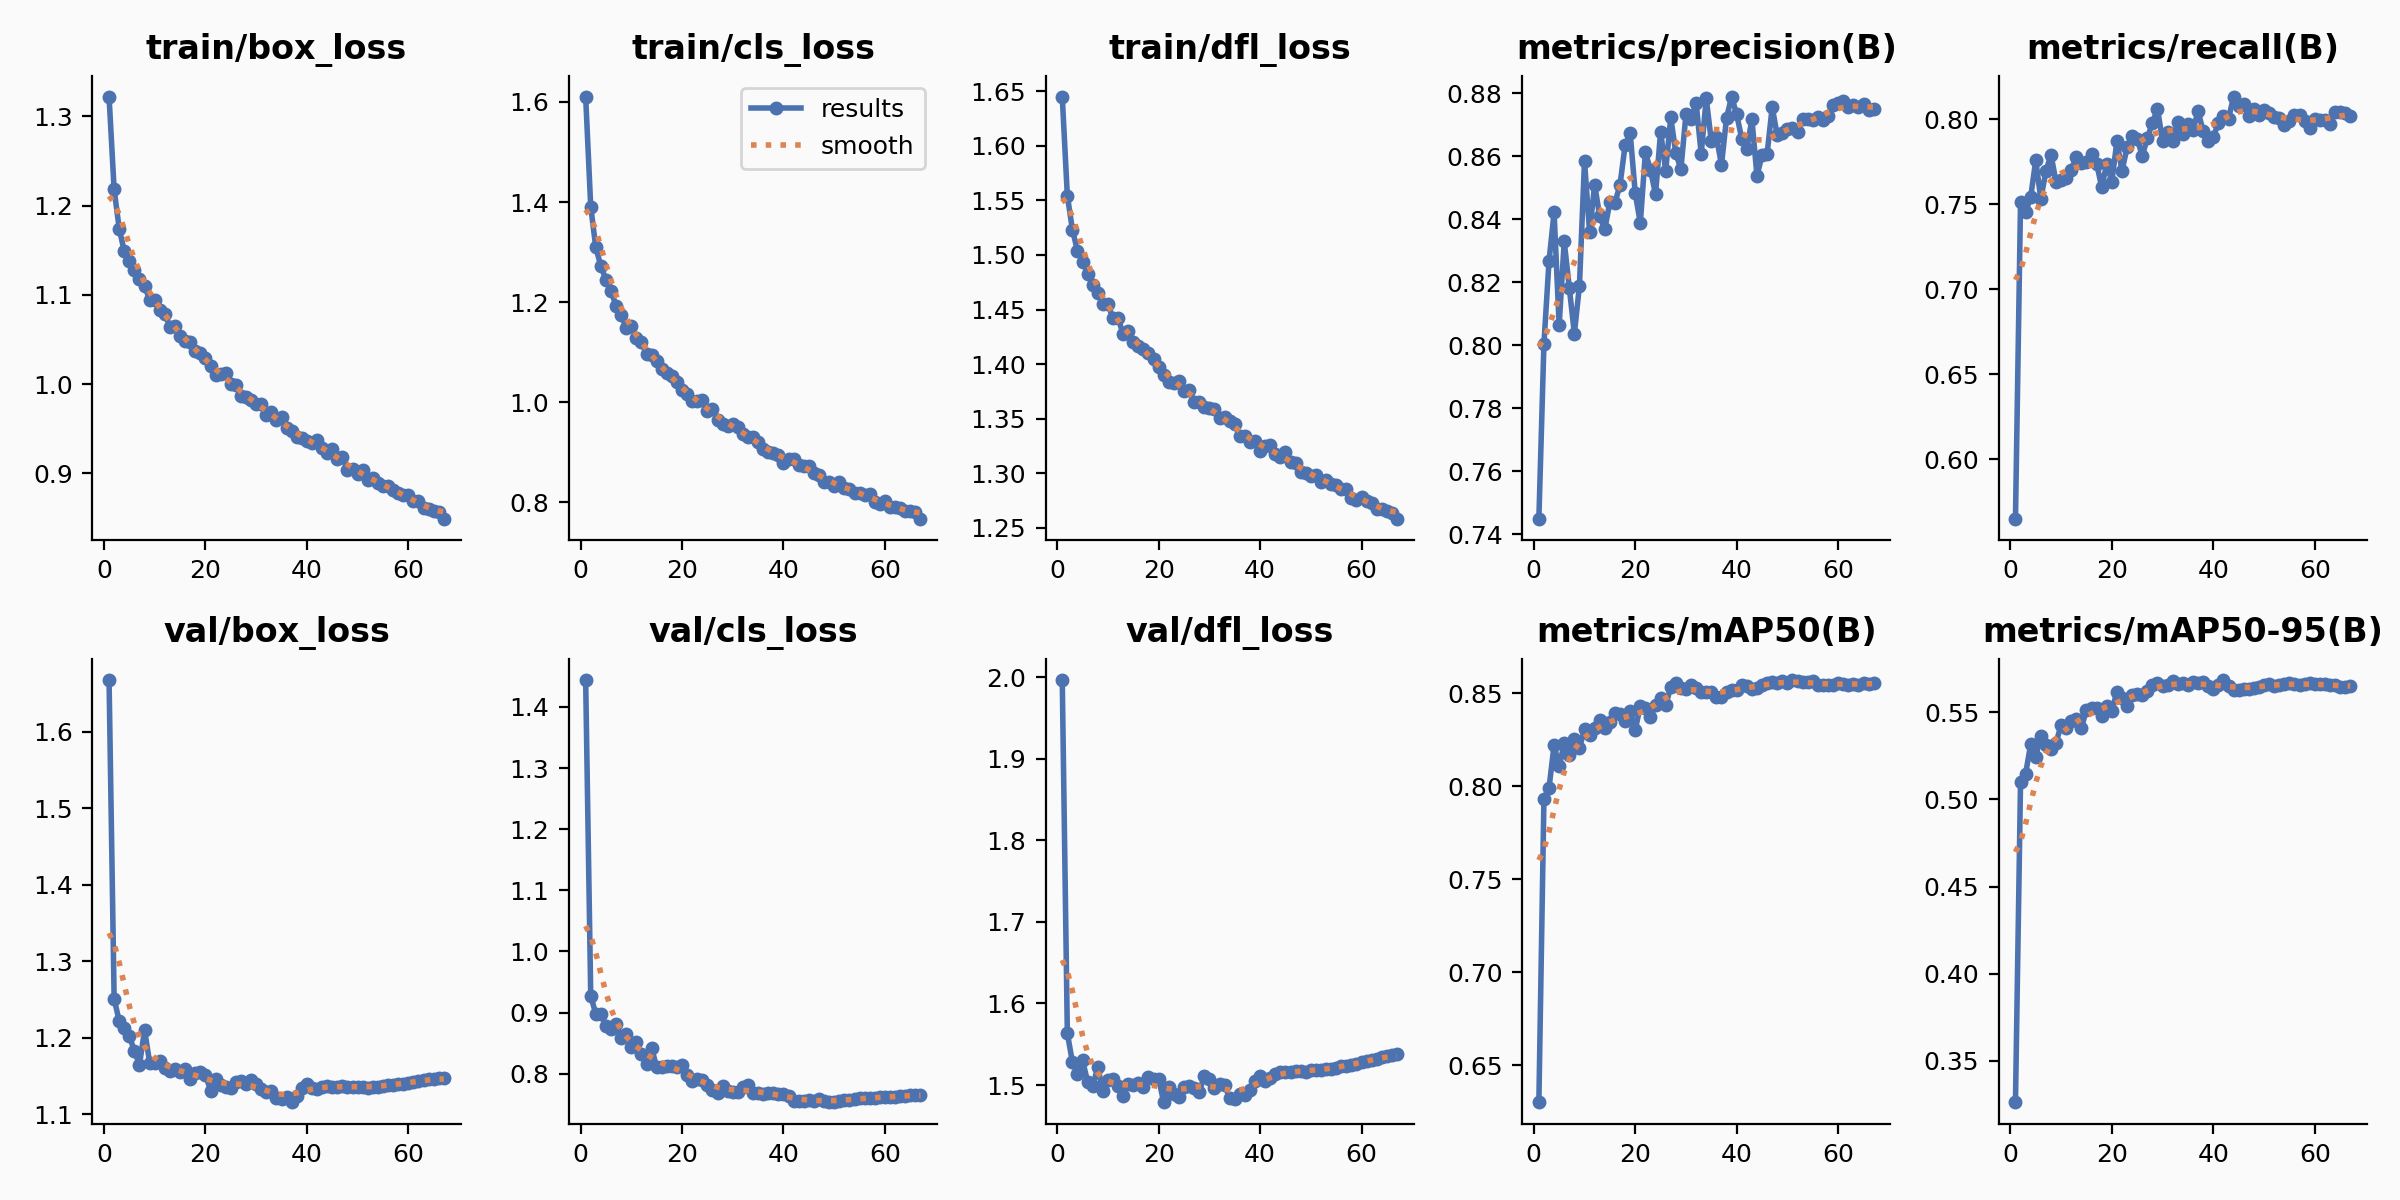

In [10]:
from IPython.display import Image, display
results_img = os.path.join(
    RUNS_DIR,
    PROJECT_NAME_FT,
    RUN_NAME_STAGE2,
    "results.png"
)

display(Image(filename=results_img))

---
## Phase 4 — Training History Visualisation (Stage 1 + Stage 2)


Stage 1: c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage1
Stage 2: c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage2
Stage 1 epochs : 19
Stage 2 epochs : 67
Combined epochs: 86


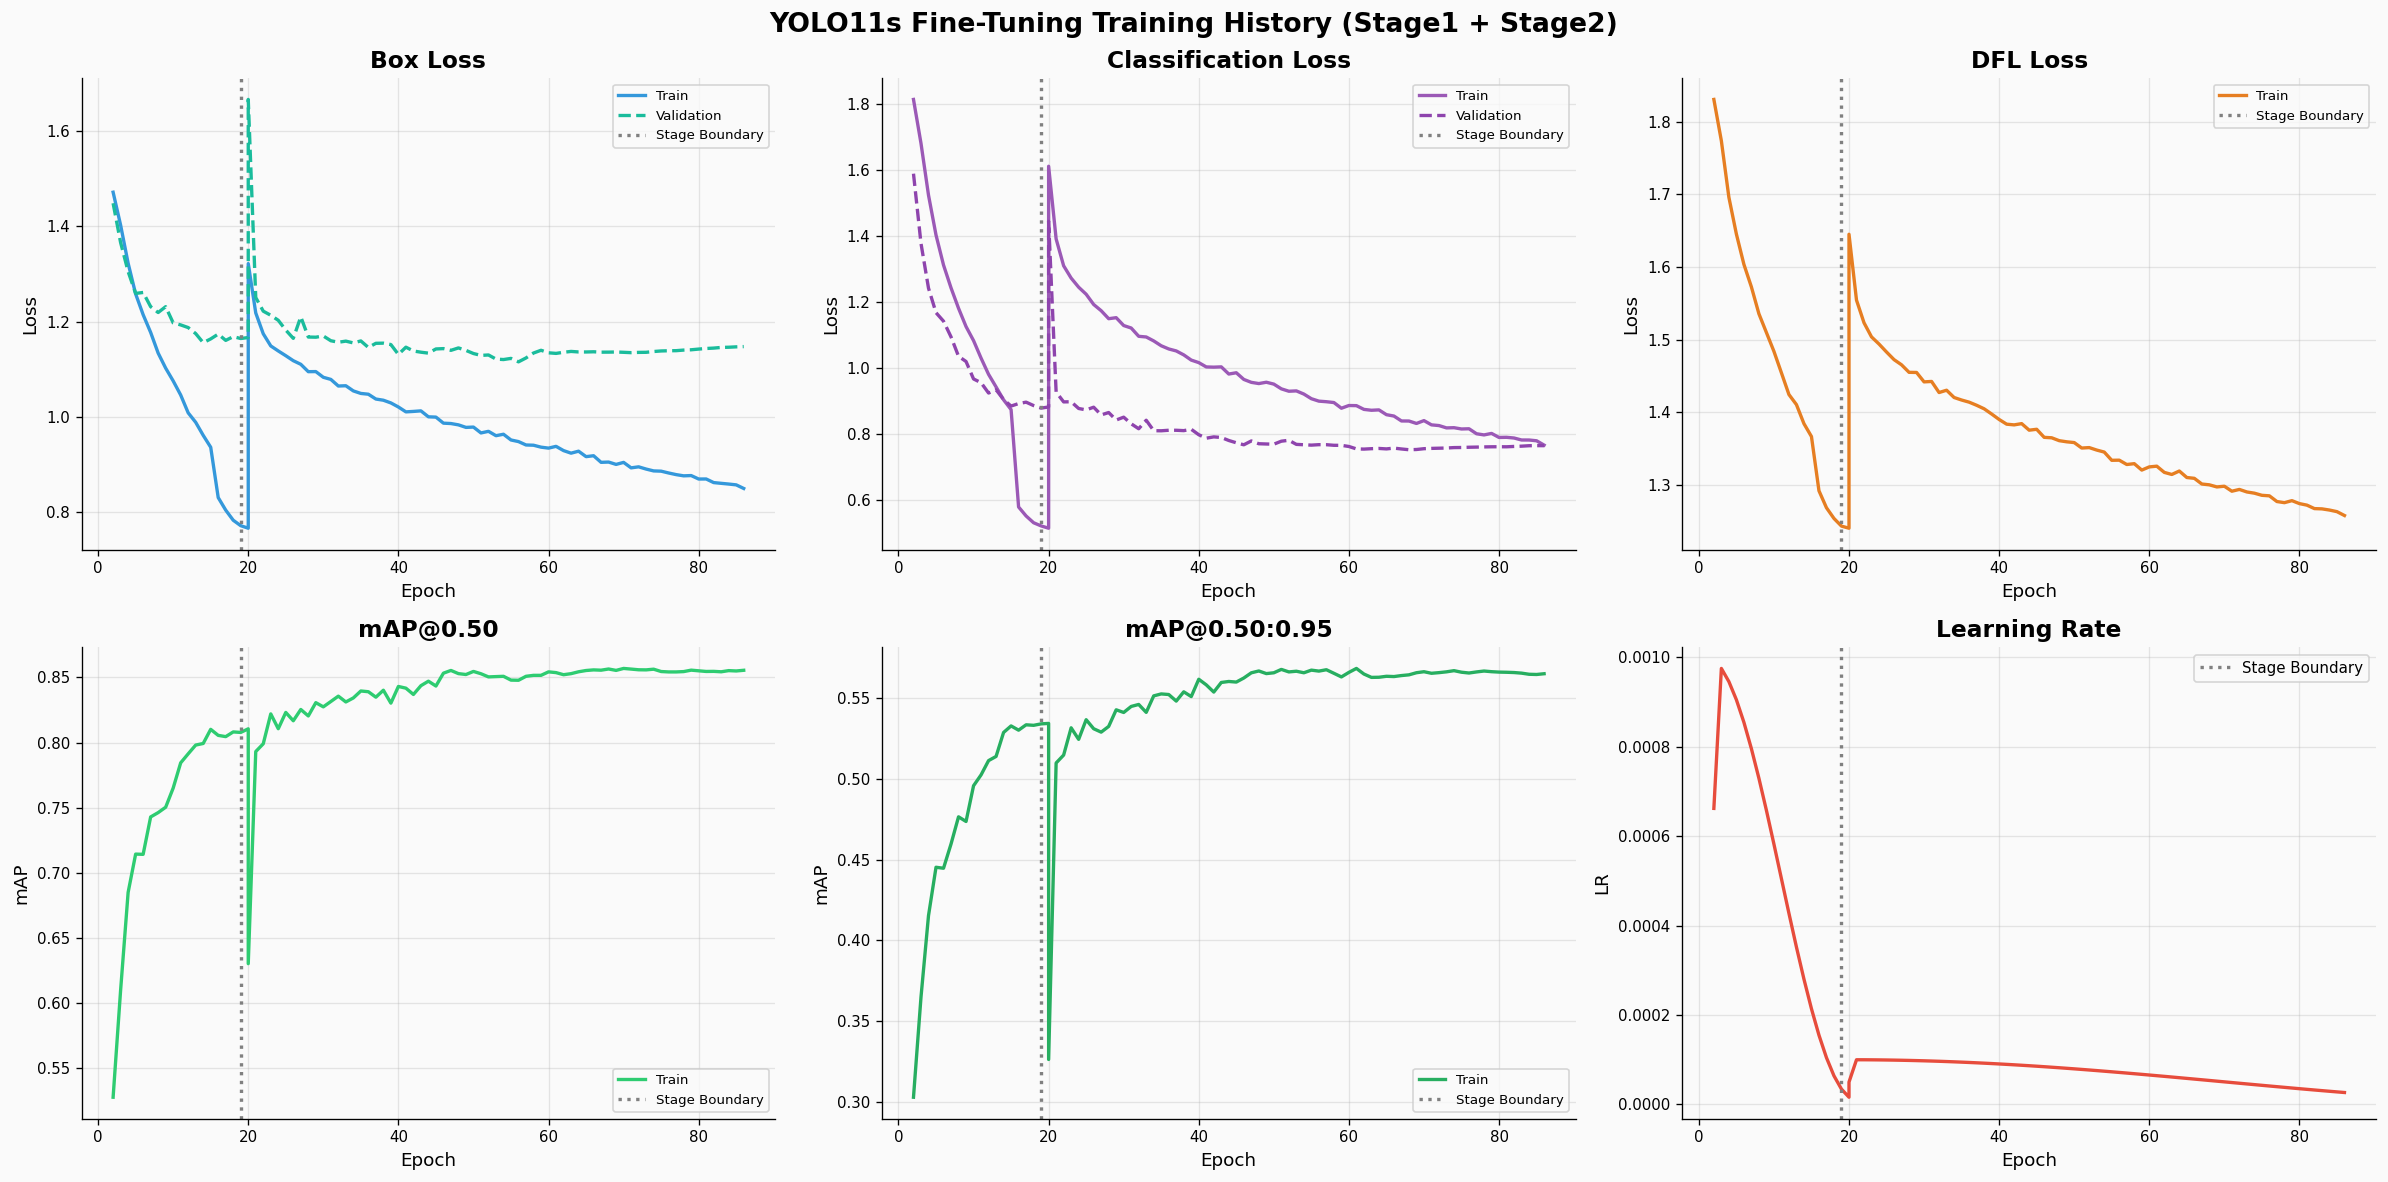

In [ ]:



def load_yolo_results_csv(run_dir: str) -> pd.DataFrame:
    """Load results.csv from a YOLO run directory."""
    csv_path = os.path.join(run_dir, "results.csv")

    if not os.path.isfile(csv_path):
        print(f"⚠ results.csv not found:\n{csv_path}")
        return pd.DataFrame()

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    return df


# --------------------------------------------------------------------------
# Paths
# --------------------------------------------------------------------------

RUNS_DIR = os.path.join(os.getcwd(), "runs", "detect")

run_dir_s1 = os.path.join(
    RUNS_DIR,
    PROJECT_NAME_FT,
    RUN_NAME_STAGE1
)

run_dir_s2 = os.path.join(
    RUNS_DIR,
    PROJECT_NAME_FT,
    RUN_NAME_STAGE2
)

print("=" * 70)
print("Stage 1:", run_dir_s1)
print("Stage 2:", run_dir_s2)
print("=" * 70)

# --------------------------------------------------------------------------
# Load CSV files
# --------------------------------------------------------------------------

df_s1 = load_yolo_results_csv(run_dir_s1)
df_s2 = load_yolo_results_csv(run_dir_s2)

if df_s1.empty and df_s2.empty:
    raise FileNotFoundError("No results.csv files were found.")

# --------------------------------------------------------------------------
# Continue epoch numbering
# --------------------------------------------------------------------------

offset = len(df_s1)

if not df_s2.empty and "epoch" in df_s2.columns:
    df_s2 = df_s2.copy()
    df_s2["epoch"] += offset

df_combined = (
    pd.concat([df_s1, df_s2], ignore_index=True)
    if not df_s1.empty else df_s2
)

print(f"Stage 1 epochs : {len(df_s1)}")
print(f"Stage 2 epochs : {len(df_s2)}")
print(f"Combined epochs: {len(df_combined)}")

# --------------------------------------------------------------------------
# Find columns
# --------------------------------------------------------------------------

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


col_box_loss = find_col(df_combined, [
    "train/box_loss",
    "train/box_om",
    "box_loss"
])

col_cls_loss = find_col(df_combined, [
    "train/cls_loss",
    "cls_loss"
])

col_dfl_loss = find_col(df_combined, [
    "train/dfl_loss",
    "dfl_loss"
])

col_val_box = find_col(df_combined, [
    "val/box_loss",
    "val/box_om"
])

col_val_cls = find_col(df_combined, [
    "val/cls_loss"
])

col_map50 = find_col(df_combined, [
    "metrics/mAP50(B)",
    "metrics/mAP_0.5",
    "mAP_0.5"
])

col_map5095 = find_col(df_combined, [
    "metrics/mAP50-95(B)",
    "metrics/mAP_0.5:0.95",
    "mAP_0.5:0.95"
])

col_lr = find_col(df_combined, [
    "lr/pg0",
    "lr/pg1",
    "lr/pg2",
    "lr"
])

# --------------------------------------------------------------------------
# Plot
# --------------------------------------------------------------------------

x_all = df_combined.get("epoch", pd.RangeIndex(len(df_combined)))
stage1_end = len(df_s1)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

fig.suptitle(
    "YOLO11s Fine-Tuning Training History (Stage1 + Stage2)",
    fontsize=16,
    fontweight="bold"
)


def plot_metric(ax,
                train_col,
                title,
                ylabel,
                train_color,
                val_col=None,
                val_color="red"):

    if train_col:
        ax.plot(
            x_all,
            df_combined[train_col],
            color=train_color,
            linewidth=2,
            label="Train"
        )

    if val_col:
        ax.plot(
            x_all,
            df_combined[val_col],
            "--",
            color=val_color,
            linewidth=2,
            label="Validation"
        )

    ax.axvline(
        stage1_end,
        color="gray",
        linestyle=":",
        linewidth=2,
        label="Stage Boundary"
    )

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)


plot_metric(
    axes[0, 0],
    col_box_loss,
    "Box Loss",
    "Loss",
    "#3498DB",
    col_val_box,
    "#1ABC9C"
)

plot_metric(
    axes[0, 1],
    col_cls_loss,
    "Classification Loss",
    "Loss",
    "#9B59B6",
    col_val_cls,
    "#8E44AD"
)

plot_metric(
    axes[0, 2],
    col_dfl_loss,
    "DFL Loss",
    "Loss",
    "#E67E22"
)

plot_metric(
    axes[1, 0],
    col_map50,
    "mAP@0.50",
    "mAP",
    "#2ECC71"
)

plot_metric(
    axes[1, 1],
    col_map5095,
    "mAP@0.50:0.95",
    "mAP",
    "#27AE60"
)

if col_lr:

    axes[1, 2].plot(
        x_all,
        df_combined[col_lr],
        color="#E74C3C",
        linewidth=2
    )

    axes[1, 2].axvline(
        stage1_end,
        color="gray",
        linestyle=":",
        linewidth=2,
        label="Stage Boundary"
    )

    axes[1, 2].set_title("Learning Rate")
    axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].set_ylabel("LR")
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].legend()

else:
    axes[1, 2].axis("off")
    axes[1, 2].set_title("Learning Rate (Unavailable)")

plt.tight_layout()

# --------------------------------------------------------------------------
# Show only (NO SAVE)
# --------------------------------------------------------------------------

plt.show()


---
## Phase 5 — Evaluation on Test Set (Fine-Tuned Model)


In [6]:
# ── Load best fine-tuned weights ──────────────────────────────────────────────


# Stage 2 run directory
stage2_dir = os.path.join(
    RUNS_DIR,
    PROJECT_NAME_FT,
    RUN_NAME_STAGE2
)

stage2_best = os.path.join(stage2_dir, "weights", "best.pt")
stage2_last = os.path.join(stage2_dir, "weights", "last.pt")

if os.path.exists(stage2_best):
    weights_path = stage2_best
elif os.path.exists(stage2_last):
    weights_path = stage2_last
    print(f"⚠️ best.pt not found — using {weights_path}")
else:
    raise FileNotFoundError(
        f"No checkpoint found.\n"
        f"Checked:\n{stage2_best}\n{stage2_last}"
    )

print(f"\nEvaluating weights:\n{weights_path}\n")

model_eval = YOLO(weights_path)

metrics_ft = model_eval.val(
    data=DATA_YAML,
    split="test",
    imgsz=IMG_SIZE_FT,
    batch=BATCH_FT,
    device=DEVICE_YOLO,
    workers=WORKERS_FT,
    verbose=True,
    plots=True,
    save_json=True,
    iou=0.6,
    conf=0.001,
)

# ── Per-class metrics table ───────────────────────────────────────────────────

print("\n" + "=" * 65)
print("  Per-class Metrics — Fine-Tuned YOLO11s (Test Set)")
print("=" * 65)
print(f"  {'Class':<12}  {'mAP@0.50':>10}  {'mAP@0.5:0.95':>13}  {'Precision':>10}  {'Recall':>8}")
print("  " + "-" * 60)

rows_ft = []

for i, idx in enumerate(metrics_ft.box.ap_class_index):
    cls_name = CLASSES[idx] if idx < NC else f"Class {idx}"

    row = {
        "Class": cls_name,
        "mAP@0.50": round(metrics_ft.box.ap50[i], 4),
        "mAP@0.50:0.95": round(metrics_ft.box.ap[i], 4),
        "Precision": round(metrics_ft.box.p[i] if hasattr(metrics_ft.box, "p") else float("nan"), 4),
        "Recall": round(metrics_ft.box.r[i] if hasattr(metrics_ft.box, "r") else float("nan"), 4),
    }

    rows_ft.append(row)

    print(
        f"  {cls_name:<12}"
        f"  {row['mAP@0.50']:>10.4f}"
        f"  {row['mAP@0.50:0.95']:>13.4f}"
        f"  {row['Precision']:>10.4f}"
        f"  {row['Recall']:>8.4f}"
    )

print("  " + "-" * 60)
print(
    f"  {'ALL (mean)':<12}"
    f"  {metrics_ft.box.map50:>10.4f}"
    f"  {metrics_ft.box.map:>13.4f}"
    f"  {metrics_ft.box.mp:>10.4f}"
    f"  {metrics_ft.box.mr:>8.4f}"
)
print("=" * 65)

df_ft = pd.DataFrame(rows_ft)


Evaluating weights:
c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage2\weights\best.pt

Ultralytics 8.4.83  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX 2000 Ada Generation, 16380MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 826.8183.4 MB/s, size: 58.7 KB)
val: Scanning C:\Users\Admin\Downloads\weapon detection\weapon_detection_augmented\test\labels.cache... 726 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 726/726  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 5.4it/s 8.5s0.2s
                   all        726       1023      0.878      0.775      0.846      0.553
                 Knife        166        198      0.853       0.73      0.796      0.471
                Pistol        361        438      0.896      0.804      0.875      0.617
              

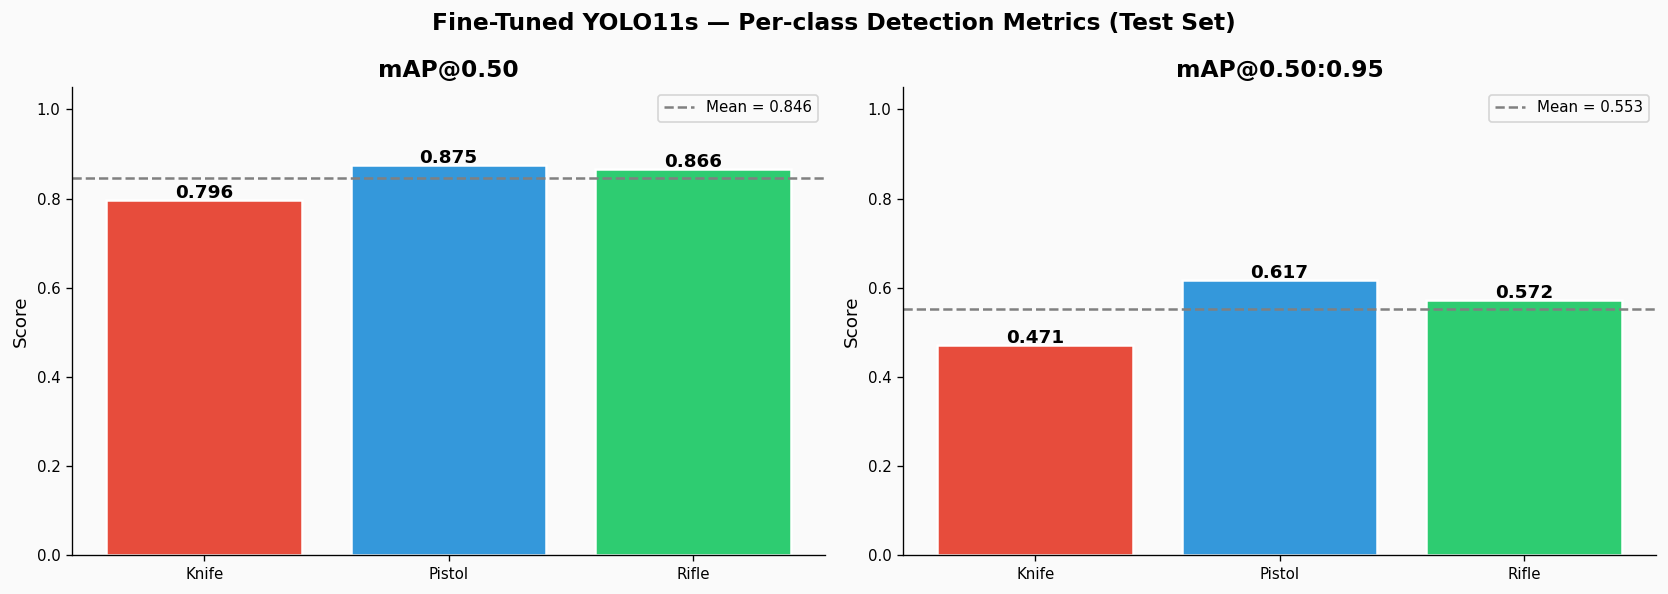

In [7]:
# ── Per-class metrics bar chart ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Fine-Tuned YOLO11s — Per-class Detection Metrics (Test Set)",
    fontsize=14,
    fontweight="bold"
)

for ax, col in zip(axes, ["mAP@0.50", "mAP@0.50:0.95"]):

    bars = ax.bar(
        df_ft["Class"],
        df_ft[col],
        color=[CLASS_COLORS.get(c, "#999999") for c in df_ft["Class"]],
        edgecolor="white",
        linewidth=1.5,
    )

    for b in bars:
        ax.text(
            b.get_x() + b.get_width()/2,
            b.get_height() + 0.005,
            f"{b.get_height():.3f}",
            ha="center",
            fontsize=11,
            fontweight="bold",
        )

    mean_val = metrics_ft.box.map50 if col == "mAP@0.50" else metrics_ft.box.map

    ax.axhline(
        mean_val,
        color="gray",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {mean_val:.3f}"
    )

    ax.set_title(col)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()



Image shape: (1500, 2250, 3)


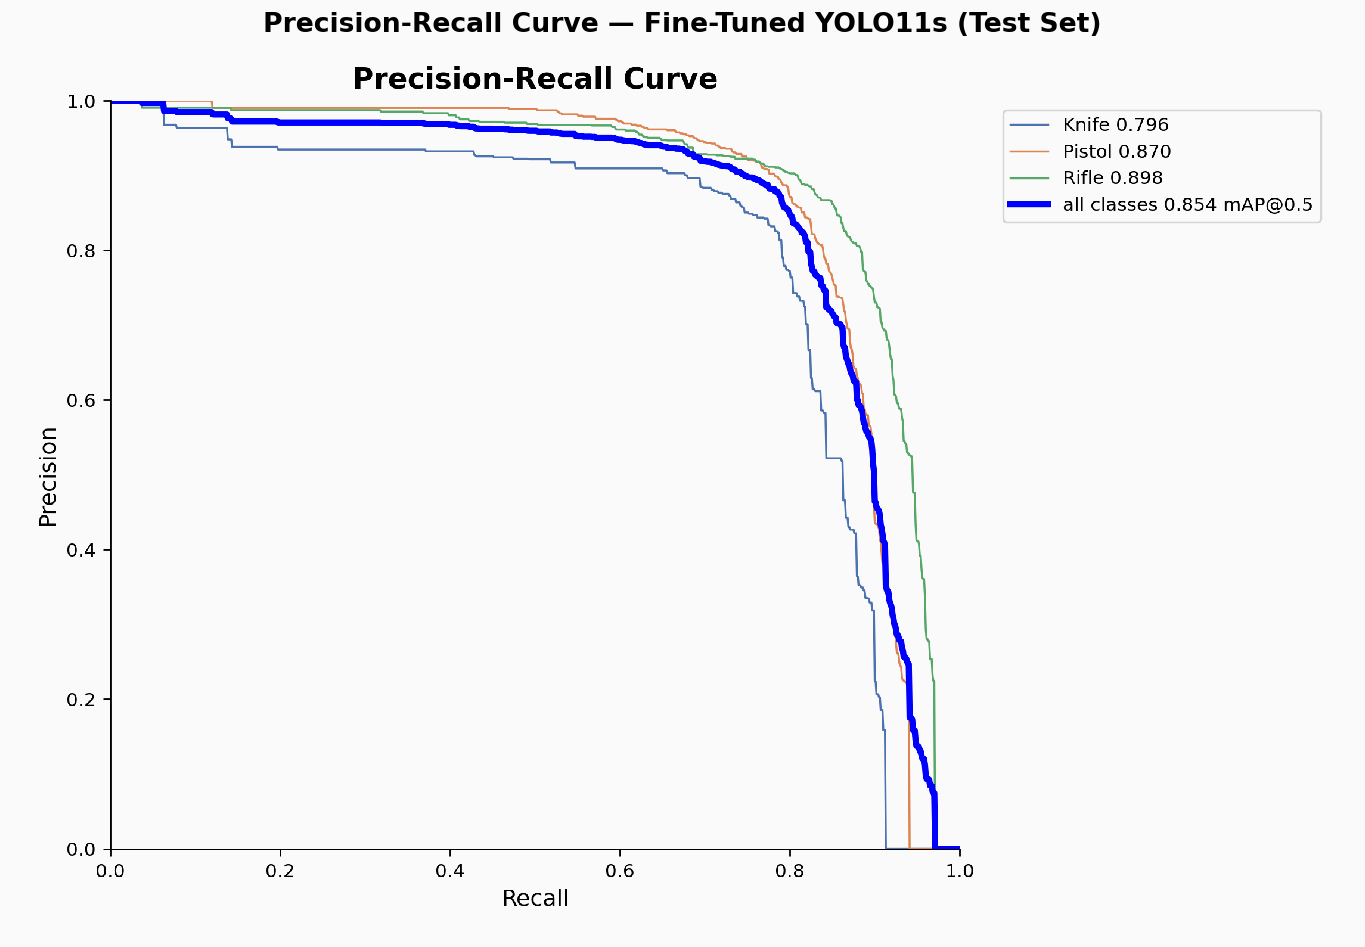


Loaded from:
c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage2\BoxPR_curve.png


In [22]:
# PR Curve path

pr_path = os.path.join(
    RUNS_DIR,
    PROJECT_NAME_FT,
    RUN_NAME_STAGE2,
    "BoxPR_curve.png"
)

if not os.path.exists(pr_path):
    print(f"BoxPR_curve.png was not found.\nChecked:\n{pr_path}")

else:
    # Read image
    img = cv2.imread(pr_path)

    if img is None:
        print("Failed to read image.")
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        print("Image shape:", img.shape)

        plt.close("all")
        plt.figure(figsize=(12, 8))

        plt.imshow(img, interpolation="nearest")
        plt.title(
            "Precision-Recall Curve — Fine-Tuned YOLO11s (Test Set)",
            fontsize=16,
            fontweight="bold"
        )
        plt.axis("off")

        plt.tight_layout()
        plt.show(block=True)

        print(f"\nLoaded from:\n{pr_path}")

Image shape: (2250, 3000, 3)


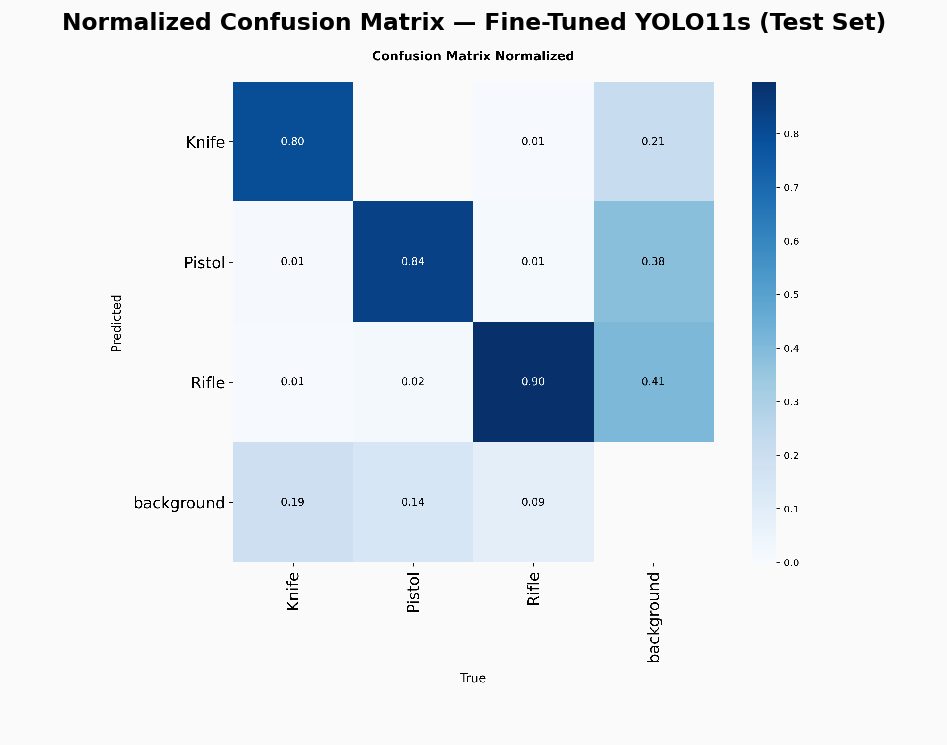


Loaded from:
c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage2\confusion_matrix_normalized.png


In [24]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────

cm_candidates = [
    os.path.join(
        RUNS_DIR,
        PROJECT_NAME_FT,
        RUN_NAME_STAGE2,
        "confusion_matrix_normalized.png"
    ),
    os.path.join(
        RUNS_DIR,
        PROJECT_NAME_FT,
        RUN_NAME_STAGE2,
        "confusion_matrix.png"
    ),
]

cm_path = next((p for p in cm_candidates if os.path.exists(p)), None)

if cm_path:

    img = cv2.imread(cm_path)

    if img is None:
        print("Failed to read confusion matrix image.")

    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        print("Image shape:", img.shape)

        plt.close("all")
        plt.figure(figsize=(8, 7))

        plt.imshow(img, interpolation="nearest")
        plt.axis("off")
        plt.title(
            "Normalized Confusion Matrix — Fine-Tuned YOLO11s (Test Set)",
            fontsize=14,
            fontweight="bold"
        )

        plt.tight_layout()
        plt.show()

        print(f"\nLoaded from:\n{cm_path}")

else:

    print("=" * 70)
    print("Confusion matrix image was not found.")
    print("Checked the following locations:\n")

    for path in cm_candidates:
        print(path)

    print("=" * 70)

---
## Phase 6 — Qualitative Evaluation: Sample Predictions on Test Images


Running inference on 12 test images (conf ≥ 0.25)...


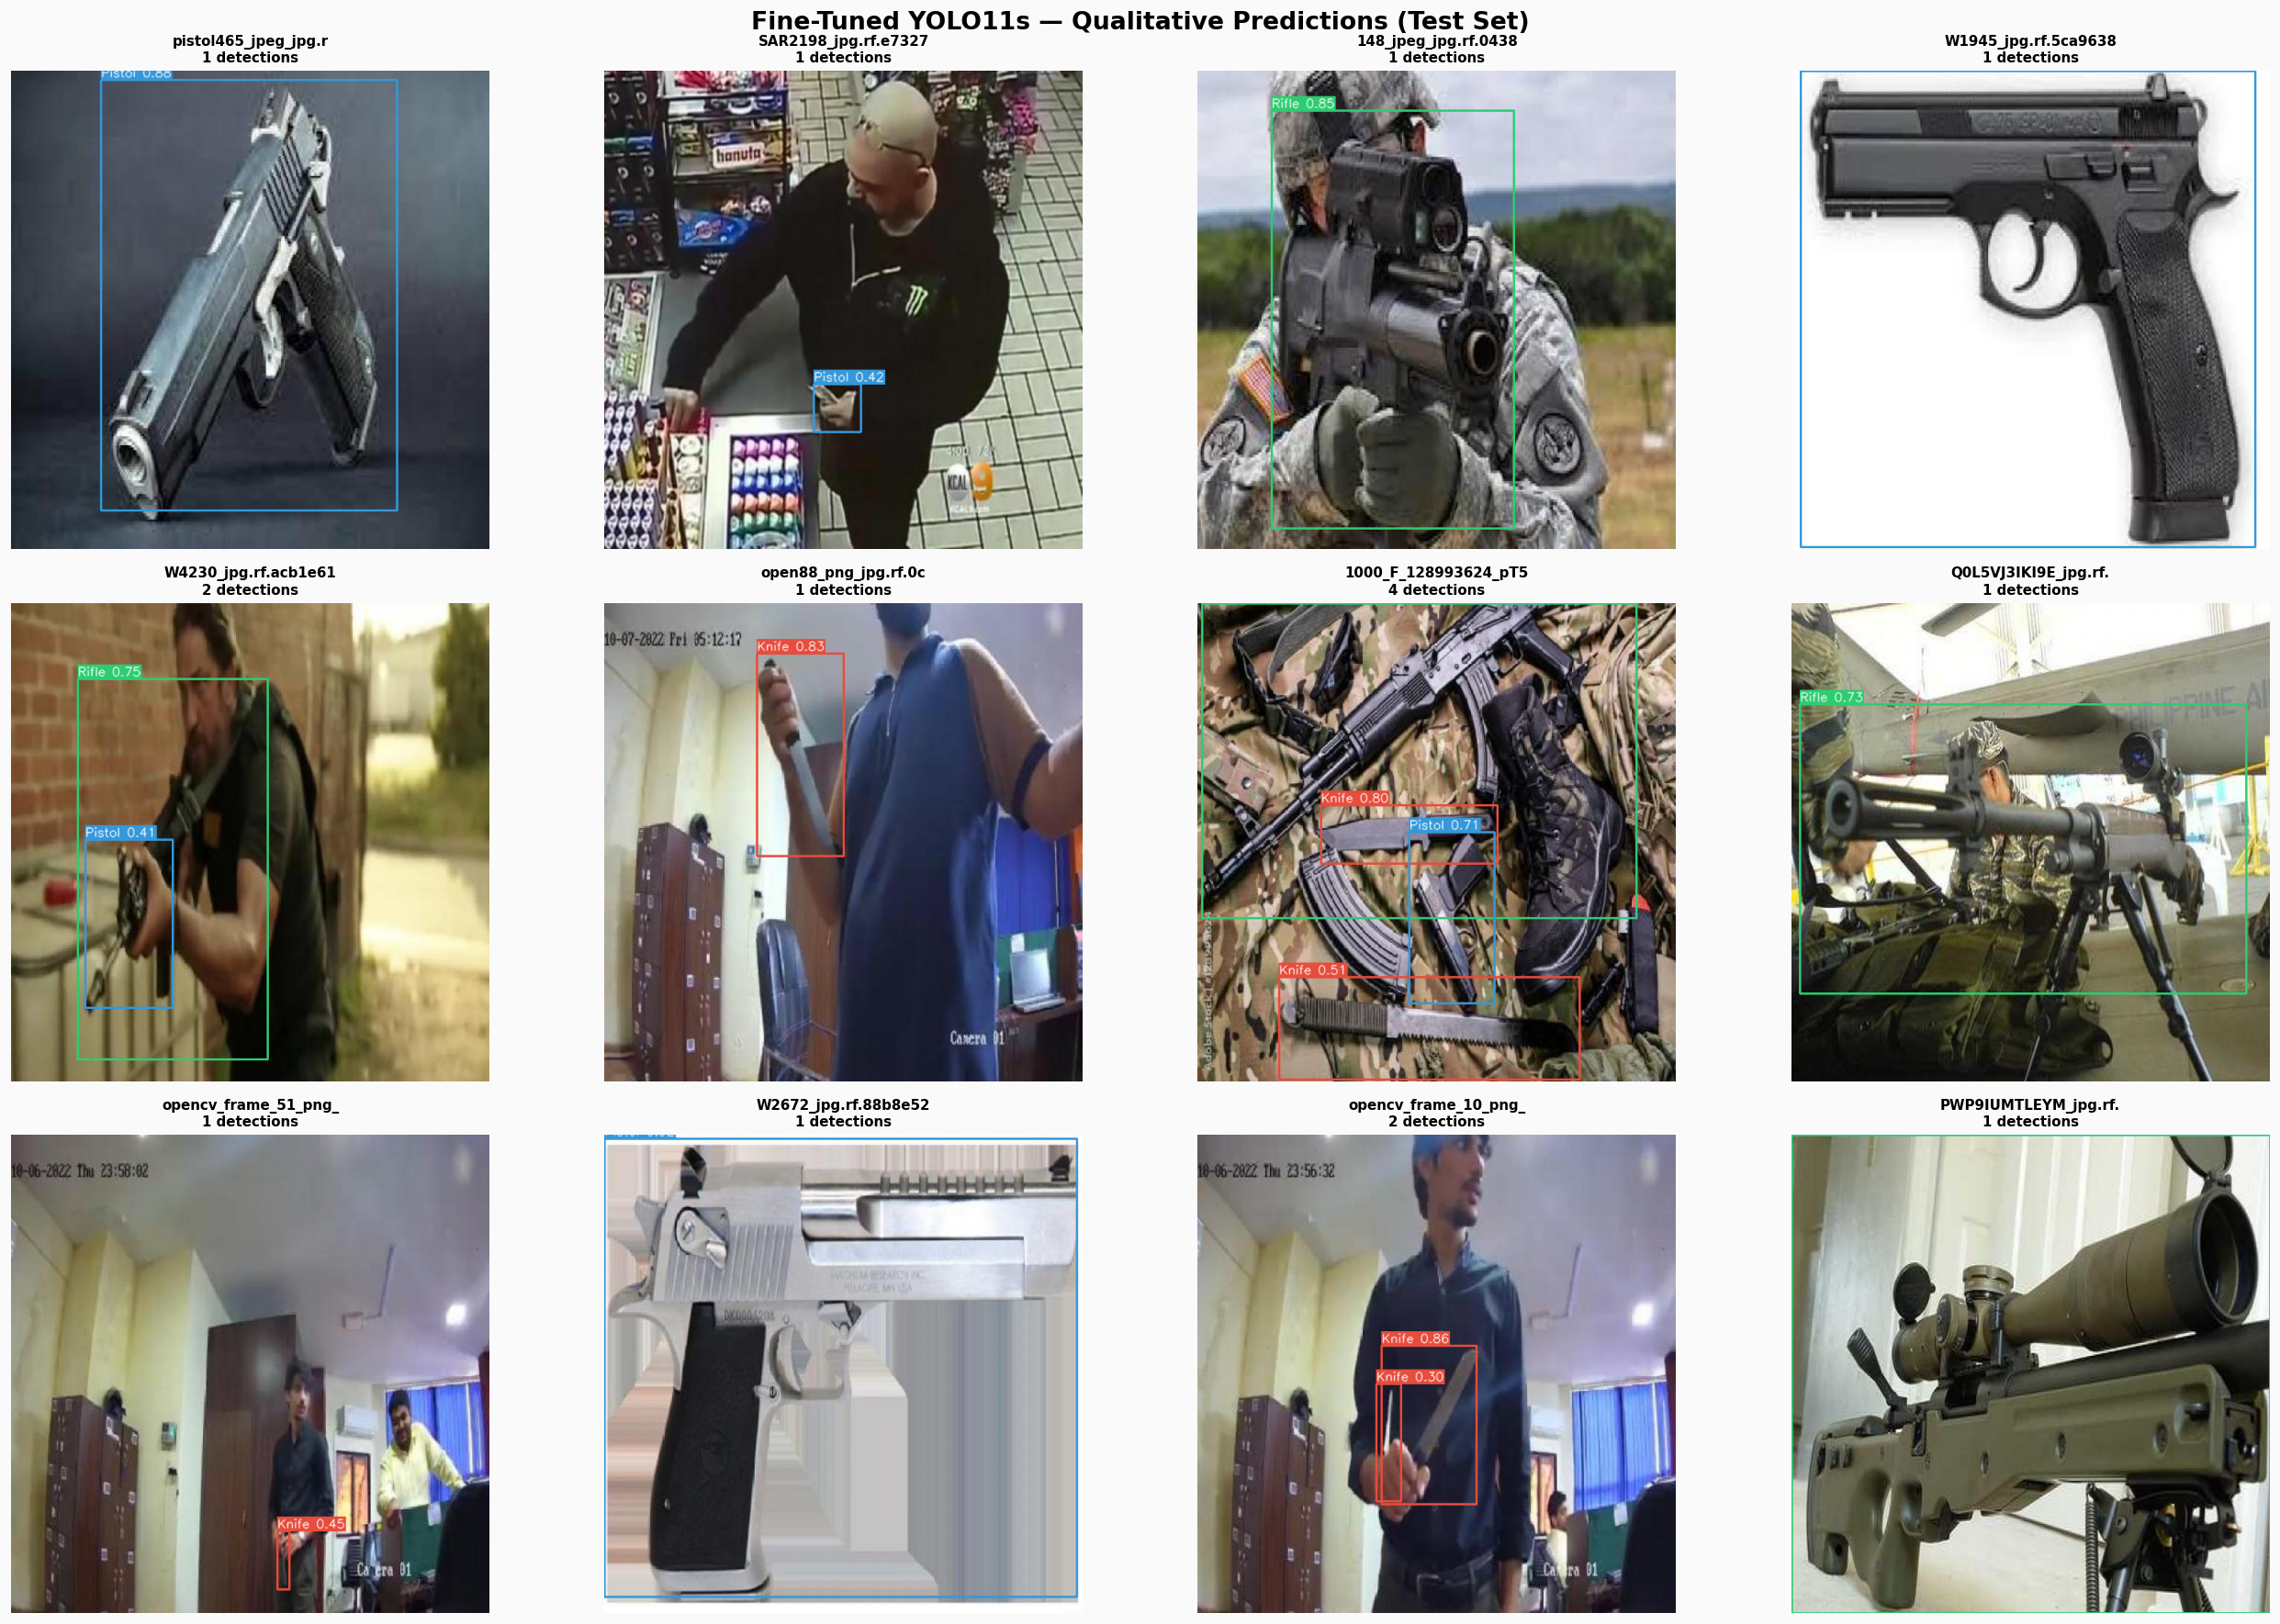


Qualitative predictions saved successfully.
c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage2\ft_qualitative_predictions.png


In [26]:
# ── Qualitative Predictions ───────────────────────────────────────────────────

test_img_dir = os.path.join(AUGMENTED_PATH, "test", "images")

test_imgs = [
    f for f in os.listdir(test_img_dir)
    if f.lower().endswith(IMAGE_EXTENSIONS)
]

N_SAMPLES = 12
CONF_THRESH = 0.25
IOU_THRESH = 0.45

sample_imgs = random.sample(test_imgs, min(N_SAMPLES, len(test_imgs)))

print(f"Running inference on {len(sample_imgs)} test images (conf ≥ {CONF_THRESH})...")

fig, axes = plt.subplots(3, 4, figsize=(22, 15))

fig.suptitle(
    "Fine-Tuned YOLO11s — Qualitative Predictions (Test Set)",
    fontsize=16,
    fontweight="bold"
)

for ax, fname in zip(axes.flat, sample_imgs):

    img_path = os.path.join(test_img_dir, fname)

    result = model_eval.predict(
        source=img_path,
        conf=CONF_THRESH,
        iou=IOU_THRESH,
        device=DEVICE_YOLO,
        verbose=False
    )[0]

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    for box in result.boxes:

        cls_id = int(box.cls.item())
        conf = float(box.conf.item())

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        cls_name = CLASSES[cls_id] if cls_id < NC else str(cls_id)

        color_hex = CLASS_COLORS.get(cls_name, "#FFFFFF")

        color = tuple(
            int(color_hex.lstrip("#")[i:i+2], 16)
            for i in (0, 2, 4)
        )

        cv2.rectangle(
            img_rgb,
            (x1, y1),
            (x2, y2),
            color,
            2
        )

        label = f"{cls_name} {conf:.2f}"

        (tw, th), _ = cv2.getTextSize(
            label,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            1
        )

        cv2.rectangle(
            img_rgb,
            (x1, y1 - th - 6),
            (x1 + tw, y1),
            color,
            -1
        )

        cv2.putText(
            img_rgb,
            label,
            (x1, y1 - 4),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )

    ax.imshow(img_rgb)
    ax.axis("off")
    ax.set_title(
        f"{fname[:20]}\n{len(result.boxes)} detections",
        fontsize=9
    )

for ax in axes.flat[len(sample_imgs):]:
    ax.axis("off")

plt.tight_layout()

# Save inside Stage 2 directory
save_path = os.path.join(
    RUNS_DIR,
    PROJECT_NAME_FT,
    RUN_NAME_STAGE2,
    "ft_qualitative_predictions.png"
)

plt.savefig(
    save_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print("Qualitative predictions saved successfully.")
print(save_path)
print("=" * 70)

---
## Phase 7 — Comparison Dashboard: Scratch vs Fine-Tuned

Compare results from **Notebook 1 Part B** (YOLO11s from scratch) against the  
fine-tuned model. Load the scratch metrics from its saved run folder.


In [31]:
# ── Load Scratch Model Metrics for Comparison ────────────────────────────────

# Scratch project runs directory
SCRATCH_RUNS_DIR = r"c:\Users\Admin\Downloads\weapon detection\yolo11s\runs\detect"

scratch_dir = os.path.join(
    SCRATCH_RUNS_DIR,
    "weapon_detection",
    "yolo11s_scratch"
)

scratch_best_pt = os.path.join(scratch_dir, "weights", "best.pt")
scratch_last_pt = os.path.join(scratch_dir, "weights", "last.pt")

if os.path.exists(scratch_best_pt):
    scratch_weights = scratch_best_pt

elif os.path.exists(scratch_last_pt):
    scratch_weights = scratch_last_pt
    print(f"best.pt was not found. Using:\n{scratch_weights}")

else:
    raise FileNotFoundError(
        f"No Scratch checkpoint was found.\n\n"
        f"Checked:\n"
        f"{scratch_best_pt}\n"
        f"{scratch_last_pt}"
    )

print(f"\nLoading Scratch model:\n{scratch_weights}\n")

model_scratch_cmp = YOLO(scratch_weights)

metrics_scratch_cmp = model_scratch_cmp.val(
    data=DATA_YAML,
    split="test",
    imgsz=IMG_SIZE_FT,
    batch=BATCH_FT,
    device=DEVICE_YOLO,
    workers=WORKERS_FT,
    verbose=False,
    plots=False,
)

scratch_map50 = metrics_scratch_cmp.box.map50
scratch_map5095 = metrics_scratch_cmp.box.map
scratch_prec = metrics_scratch_cmp.box.mp
scratch_rec = metrics_scratch_cmp.box.mr

rows_scratch = []

for i, idx in enumerate(metrics_scratch_cmp.box.ap_class_index):

    cls_name = CLASSES[idx] if idx < NC else f"Class {idx}"

    rows_scratch.append({
        "Class": cls_name,
        "mAP@0.50": round(metrics_scratch_cmp.box.ap50[i], 4),
        "mAP@0.50:0.95": round(metrics_scratch_cmp.box.ap[i], 4),
        "Precision": round(
            metrics_scratch_cmp.box.p[i]
            if hasattr(metrics_scratch_cmp.box, "p")
            else float("nan"),
            4
        ),
        "Recall": round(
            metrics_scratch_cmp.box.r[i]
            if hasattr(metrics_scratch_cmp.box, "r")
            else float("nan"),
            4
        ),
    })

df_scratch_cmp = pd.DataFrame(rows_scratch)

print("\n" + "=" * 70)
print("Scratch Model")
print(f"mAP@0.50      : {scratch_map50:.4f}")
print(f"mAP@0.50:0.95 : {scratch_map5095:.4f}")
print(f"Precision     : {scratch_prec:.4f}")
print(f"Recall        : {scratch_rec:.4f}")

print("\nFine-Tuned Model")
print(f"mAP@0.50      : {metrics_ft.box.map50:.4f}")
print(f"mAP@0.50:0.95 : {metrics_ft.box.map:.4f}")
print(f"Precision     : {metrics_ft.box.mp:.4f}")
print(f"Recall        : {metrics_ft.box.mr:.4f}")
print("=" * 70)


Loading Scratch model:
c:\Users\Admin\Downloads\weapon detection\yolo11s\runs\detect\weapon_detection\yolo11s_scratch\weights\best.pt

Ultralytics 8.4.83  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX 2000 Ada Generation, 16380MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 552.6180.9 MB/s, size: 42.1 KB)
val: Scanning C:\Users\Admin\Downloads\weapon detection\weapon_detection_augmented\test\labels.cache... 726 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 726/726  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 6.0it/s 7.7s0.2s
                   all        726       1023      0.285      0.241      0.205     0.0961
Speed: 0.3ms preprocess, 6.3ms inference, 0.0ms loss, 0.5ms postprocess per image

Scratch Model
mAP@0.50      : 0.2045
mAP@0.50:0.95 : 0.0961
Precision     : 0.2846
Recall        : 0.2411

Fine-Tuned Mo

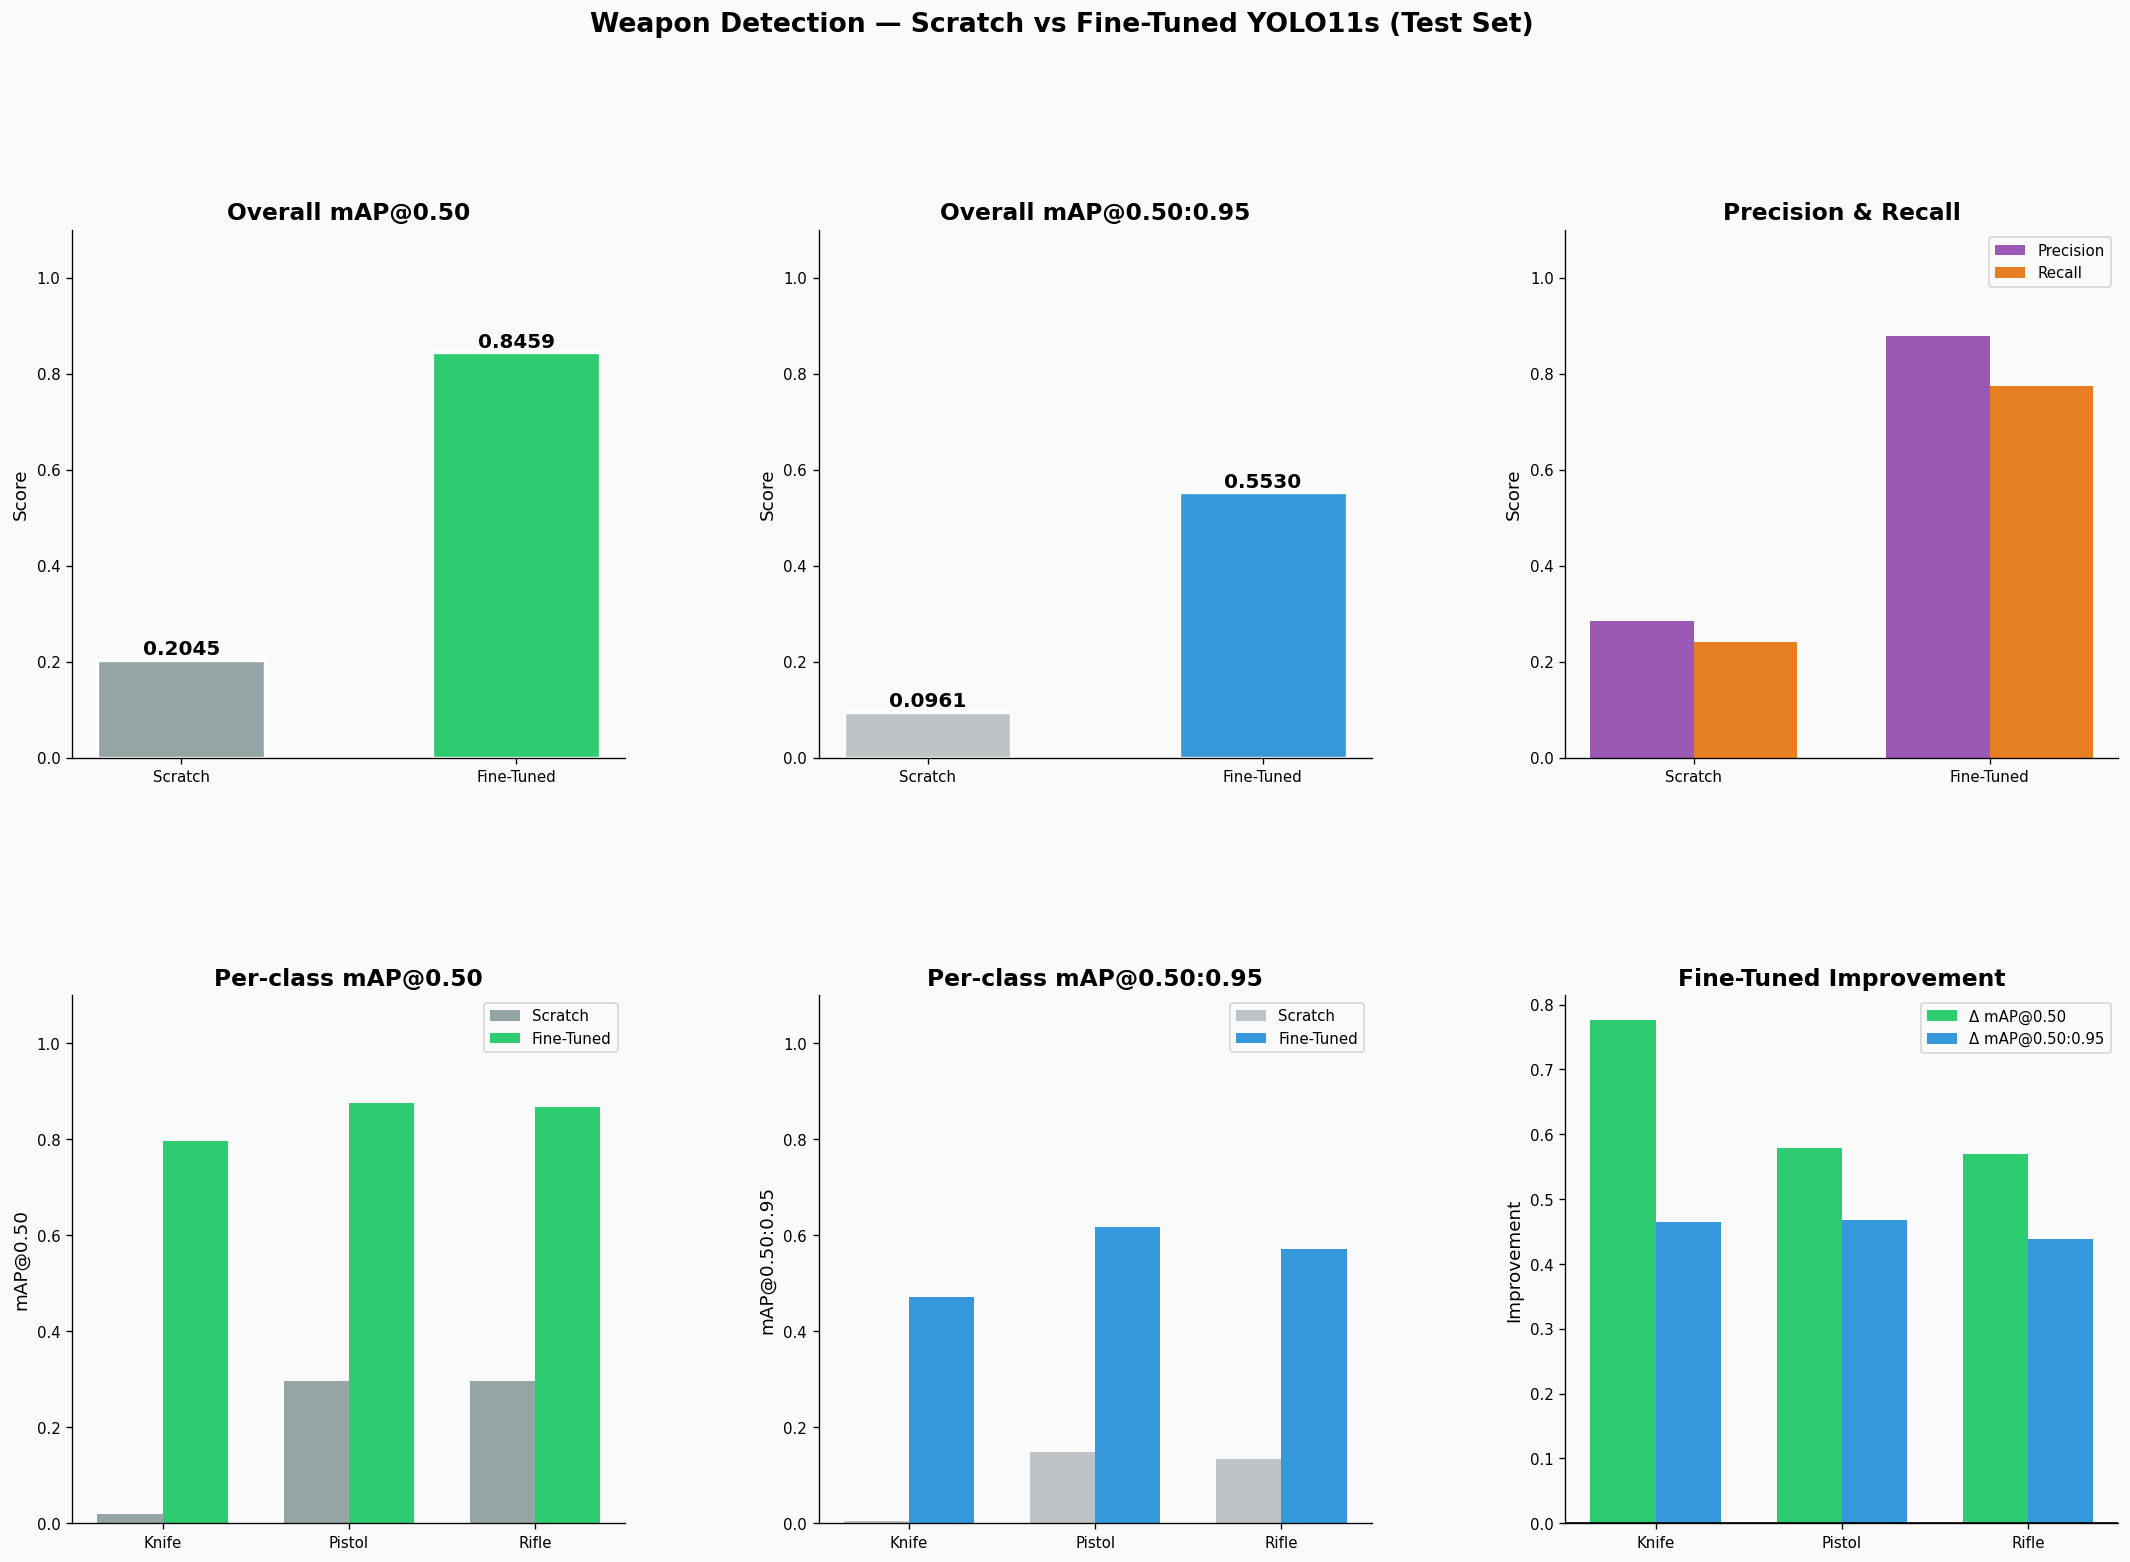


Comparison dashboard saved successfully.
c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage2\comparison_scratch_vs_finetuned.png


In [33]:
# ── Comparison Dashboard ───────────────────────────────────────────────────────

fig = plt.figure(figsize=(22, 14))
fig.suptitle(
    "Weapon Detection — Scratch vs Fine-Tuned YOLO11s (Test Set)",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

gs = gridspec.GridSpec(
    2, 3,
    figure=fig,
    hspace=0.45,
    wspace=0.35
)

# ──────────────────────────────────────────────────────────────────────────────
# Panel 1 : Overall mAP@0.50
# ──────────────────────────────────────────────────────────────────────────────

ax1 = fig.add_subplot(gs[0, 0])

models = ["Scratch", "Fine-Tuned"]
map50s = [scratch_map50, metrics_ft.box.map50]

bars = ax1.bar(
    models,
    map50s,
    color=["#95A5A6", "#2ECC71"],
    edgecolor="white",
    linewidth=2,
    width=0.5
)

for b in bars:
    ax1.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.01,
        f"{b.get_height():.4f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

ax1.set_title("Overall mAP@0.50")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.1)

# ──────────────────────────────────────────────────────────────────────────────
# Panel 2 : Overall mAP@0.50:0.95
# ──────────────────────────────────────────────────────────────────────────────

ax2 = fig.add_subplot(gs[0, 1])

map5095 = [
    scratch_map5095,
    metrics_ft.box.map
]

bars = ax2.bar(
    models,
    map5095,
    color=["#BDC3C7", "#3498DB"],
    edgecolor="white",
    linewidth=2,
    width=0.5
)

for b in bars:
    ax2.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.01,
        f"{b.get_height():.4f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

ax2.set_title("Overall mAP@0.50:0.95")
ax2.set_ylabel("Score")
ax2.set_ylim(0, 1.1)

# ──────────────────────────────────────────────────────────────────────────────
# Panel 3 : Precision & Recall
# ──────────────────────────────────────────────────────────────────────────────

ax3 = fig.add_subplot(gs[0, 2])

x = np.arange(2)
width = 0.35

ax3.bar(
    x - width / 2,
    [scratch_prec, metrics_ft.box.mp],
    width,
    label="Precision",
    color="#9B59B6"
)

ax3.bar(
    x + width / 2,
    [scratch_rec, metrics_ft.box.mr],
    width,
    label="Recall",
    color="#E67E22"
)

ax3.set_xticks(x)
ax3.set_xticklabels(models)

ax3.set_ylim(0, 1.1)
ax3.set_ylabel("Score")
ax3.set_title("Precision & Recall")
ax3.legend()

# ──────────────────────────────────────────────────────────────────────────────
# Panel 4 : Per-class mAP@0.50
# ──────────────────────────────────────────────────────────────────────────────

ax4 = fig.add_subplot(gs[1, 0])

x = np.arange(NC)
width = 0.35

scratch_values = (
    df_scratch_cmp
    .set_index("Class")
    .reindex(CLASSES)["mAP@0.50"]
    .fillna(0)
    .values
)

ft_values = (
    df_ft
    .set_index("Class")
    .reindex(CLASSES)["mAP@0.50"]
    .fillna(0)
    .values
)

ax4.bar(
    x - width / 2,
    scratch_values,
    width,
    label="Scratch",
    color="#95A5A6"
)

ax4.bar(
    x + width / 2,
    ft_values,
    width,
    label="Fine-Tuned",
    color="#2ECC71"
)

ax4.set_xticks(x)
ax4.set_xticklabels(CLASSES)
ax4.set_ylim(0, 1.1)
ax4.set_ylabel("mAP@0.50")
ax4.set_title("Per-class mAP@0.50")
ax4.legend()

# ──────────────────────────────────────────────────────────────────────────────
# Panel 5 : Per-class mAP@0.50:0.95
# ──────────────────────────────────────────────────────────────────────────────

ax5 = fig.add_subplot(gs[1, 1])

scratch_values95 = (
    df_scratch_cmp
    .set_index("Class")
    .reindex(CLASSES)["mAP@0.50:0.95"]
    .fillna(0)
    .values
)

ft_values95 = (
    df_ft
    .set_index("Class")
    .reindex(CLASSES)["mAP@0.50:0.95"]
    .fillna(0)
    .values
)

ax5.bar(
    x - width / 2,
    scratch_values95,
    width,
    label="Scratch",
    color="#BDC3C7"
)

ax5.bar(
    x + width / 2,
    ft_values95,
    width,
    label="Fine-Tuned",
    color="#3498DB"
)

ax5.set_xticks(x)
ax5.set_xticklabels(CLASSES)
ax5.set_ylim(0, 1.1)
ax5.set_ylabel("mAP@0.50:0.95")
ax5.set_title("Per-class mAP@0.50:0.95")
ax5.legend()

# ──────────────────────────────────────────────────────────────────────────────
# Panel 6 : Improvement
# ──────────────────────────────────────────────────────────────────────────────

ax6 = fig.add_subplot(gs[1, 2])

delta50 = ft_values - scratch_values
delta95 = ft_values95 - scratch_values95

ax6.bar(
    x - width / 2,
    delta50,
    width,
    label="Δ mAP@0.50",
    color="#2ECC71"
)

ax6.bar(
    x + width / 2,
    delta95,
    width,
    label="Δ mAP@0.50:0.95",
    color="#3498DB"
)

ax6.axhline(0, color="black", linewidth=1)

ax6.set_xticks(x)
ax6.set_xticklabels(CLASSES)
ax6.set_ylabel("Improvement")
ax6.set_title("Fine-Tuned Improvement")
ax6.legend()

# ──────────────────────────────────────────────────────────────────────────────
# Save Figure
# ──────────────────────────────────────────────────────────────────────────────

plt.tight_layout()

save_dir = os.path.join(
    RUNS_DIR,
    PROJECT_NAME_FT,
    RUN_NAME_STAGE2
)

os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "comparison_scratch_vs_finetuned.png"
)

plt.savefig(
    save_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print("Comparison dashboard saved successfully.")
print(save_path)
print("=" * 70)

In [35]:
# ── Final Summary Table ───────────────────────────────────────────────────────

print("\n" + "=" * 75)
print("FINAL COMPARISON — Scratch vs Fine-Tuned YOLO11s (Test Set)")
print("=" * 75)

print(
    f"{'Model':<24}"
    f"{'mAP@0.50':>12}"
    f"{'mAP@0.50:0.95':>18}"
    f"{'Precision':>14}"
    f"{'Recall':>12}"
)

print("-" * 75)

print(
    f"{'YOLO11s (Scratch)':<24}"
    f"{scratch_map50:>12.4f}"
    f"{scratch_map5095:>18.4f}"
    f"{scratch_prec:>14.4f}"
    f"{scratch_rec:>12.4f}"
)

print(
    f"{'YOLO11s (Fine-Tuned)':<24}"
    f"{metrics_ft.box.map50:>12.4f}"
    f"{metrics_ft.box.map:>18.4f}"
    f"{metrics_ft.box.mp:>14.4f}"
    f"{metrics_ft.box.mr:>12.4f}"
)

delta_map50 = metrics_ft.box.map50 - scratch_map50
delta_map95 = metrics_ft.box.map - scratch_map5095
delta_prec = metrics_ft.box.mp - scratch_prec
delta_rec = metrics_ft.box.mr - scratch_rec

print("-" * 75)

print(
    f"{'Improvement':<24}"
    f"{delta_map50:+12.4f}"
    f"{delta_map95:+18.4f}"
    f"{delta_prec:+14.4f}"
    f"{delta_rec:+12.4f}"
)

print("=" * 75)

# ──────────────────────────────────────────────────────────────────────────────
# Interpretation
# ──────────────────────────────────────────────────────────────────────────────

print("\nInterpretation")
print("-" * 75)

if delta_map50 >= 0.05:
    print(
        f"Transfer learning achieved a substantial improvement "
        f"(+{delta_map50:.4f} mAP@0.50)."
    )
    print(
        "The COCO pre-trained backbone successfully learned robust "
        "features for weapon detection."
    )

elif delta_map50 > 0:
    print(
        f"Transfer learning achieved a moderate improvement "
        f"(+{delta_map50:.4f} mAP@0.50)."
    )

else:
    print(
        "Scratch training performed similarly or better than fine-tuning."
    )
    print(
        "Longer scratch training or additional hyperparameter tuning may help."
    )

recommended_model = (
    "Fine-Tuned YOLO11s"
    if delta_map50 >= 0
    else "Scratch YOLO11s"
)

deployment_weights = (
    weights_path
    if delta_map50 >= 0
    else scratch_weights
)

print("\nRecommended model for deployment:")
print(recommended_model)

print("\nDeployment weights:")
print(deployment_weights)

print("=" * 75)


FINAL COMPARISON — Scratch vs Fine-Tuned YOLO11s (Test Set)
Model                       mAP@0.50     mAP@0.50:0.95     Precision      Recall
---------------------------------------------------------------------------
YOLO11s (Scratch)             0.2045            0.0961        0.2846      0.2411
YOLO11s (Fine-Tuned)          0.8459            0.5530        0.8782      0.7749
---------------------------------------------------------------------------
Improvement                  +0.6414           +0.4569       +0.5936     +0.5338

Interpretation
---------------------------------------------------------------------------
Transfer learning achieved a substantial improvement (+0.6414 mAP@0.50).
The COCO pre-trained backbone successfully learned robust features for weapon detection.

Recommended model for deployment:
Fine-Tuned YOLO11s

Deployment weights:
c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage2\weights\best.pt


---
## Phase 8 — Model Export for Deployment


In [5]:
# ─────────────────────────────────────────────────────────────
# Export Fine-Tuned YOLO Model to ONNX (FULL SAFE VERSION)
# ─────────────────────────────────────────────────────────────

import os
from ultralytics import YOLO

# ── Base Path (IMPORTANT) ─────────────────────────────────────
BASE_DIR = r"c:\Users\Admin\Downloads\weapon detection\yolo11sTuning"

RUNS_DIR = os.path.join(BASE_DIR, "runs", "detect")

PROJECT_NAME_FT = "weapon_detection"
RUN_NAME_STAGE2 = "yolo11s_finetune_stage2"   # غيّرها لو stage1

# ── Settings ──────────────────────────────────────────────────
DEVICE_YOLO = 0      # GPU = 0, CPU = "cpu"
IMG_SIZE_FT = 640

# ── Locate Model Directory ────────────────────────────────────
stage_dir = os.path.join(
    RUNS_DIR,
    PROJECT_NAME_FT,
    RUN_NAME_STAGE2
)

stage_best = os.path.join(stage_dir, "weights", "best.pt")
stage_last = os.path.join(stage_dir, "weights", "last.pt")

print("=" * 70)
print("Checking Stage Weights...")
print("=" * 70)

print("Best:", stage_best)
print("Last:", stage_last)

# ── Select Weights ────────────────────────────────────────────
if os.path.isfile(stage_best):
    weights_path = stage_best
    print("\n✅ Using best.pt")

elif os.path.isfile(stage_last):
    weights_path = stage_last
    print("\n⚠ best.pt not found, using last.pt")

else:
    raise FileNotFoundError(
        "❌ No model found!\n"
        f"Checked:\n{stage_best}\n{stage_last}"
    )

# ── Load Model ────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Loading YOLO Model")
print("=" * 70)

model = YOLO(weights_path)

# ── Export ONNX ───────────────────────────────────────────────
print("\n" + "=" * 70)
print("Exporting to ONNX...")
print("=" * 70)

exported_path = model.export(
    format="onnx",
    imgsz=IMG_SIZE_FT,
    opset=12,
    simplify=True,
    dynamic=False,
    device=DEVICE_YOLO
)

print("\n✅ Export completed!")

# ── Find ONNX file ────────────────────────────────────────────
print("\nSearching for ONNX file...\n")

export_dir = os.path.dirname(weights_path)

onnx_files = [f for f in os.listdir(export_dir) if f.endswith(".onnx")]

if not onnx_files:
    print("❌ No ONNX file found.")
else:
    for f in onnx_files:
        full_path = os.path.join(export_dir, f)
        size_mb = os.path.getsize(full_path) / (1024 * 1024)

        print("-" * 60)
        print("Model:", f)
        print("Path :", full_path)
        print(f"Size : {size_mb:.2f} MB")

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

Checking Stage Weights...
Best: c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage2\weights\best.pt
Last: c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage2\weights\last.pt

✅ Using best.pt

Loading YOLO Model

Exporting to ONNX...
Ultralytics 8.4.83  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX 2000 Ada Generation, 16380MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs

PyTorch: starting from 'c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_stage2\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (18.3 MB)

ONNX: starting export with onnx 1.22.0 opset 12...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  1.4s, saved as 'c:\Users\Admin\Downloads\weapon detection\yolo11sTuning\runs\detect\weapon_detection\yolo11s_finetune_st

---
## Full Pipeline Summary

| Phase | Action | Key Output |
|---|---|---|
| **1** | Load `yolo11s.pt` pre-trained on COCO | Model with COCO features |
| **2** | Stage 1 — Freeze backbone, train head | `yolo11s_finetune_stage1/weights/best.pt` |
| **3** | Stage 2 — Full fine-tuning, all layers | `yolo11s_finetune_stage2/weights/best.pt` |
| **4** | Training history visualisation | `finetune_combined_training_history.png` |
| **5** | Test set evaluation | mAP · PR curves · Confusion Matrix |
| **6** | Qualitative predictions | `ft_qualitative_predictions.png` |
| **7** | Comparison dashboard | `comparison_scratch_vs_finetuned.png` |
| **8** | ONNX export | `best.onnx` |




---

> *Notebook generated as part of the Weapon Detection Computer Vision Portfolio Project*  
